In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()


os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["LANGCHAIN_API_KEY"] = LANGCHAIN_API_KEY
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

In [44]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash")

In [23]:
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    ToolMessage,
)
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

from langgraph.graph import END, StateGraph, START

In [ ]:

# Create an agent with a given system message and list of tools
def create_agent(llm, tools, system_message: str):
    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a collaborative AI assistant. Use the provided tools to help answer the query. "
            "If you reach a final answer, prefix your response with 'FINAL ANSWER'. "
            "Available tools: {tool_names}.\n{system_message}"
        ),
        MessagesPlaceholder(variable_name="messages"),
    ])
    prompt = prompt.partial(
        system_message=system_message,
        tool_names=", ".join([tool.name for tool in tools])
    )
    return prompt | llm.bind_tools(tools)

In [25]:
from typing import Annotated
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool 
from langchain_experimental.utilities import PythonREPL

In [26]:
tavily_tool = TavilySearchResults(max_results=5)
repl = PythonREPL()

In [ ]:

@tool
def python_repl(
    code: Annotated[str, "Python code to execute and generate charts."]
):
    """Executes Python code. Print the output so the user can see it."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Executed Code:\n```python\n{code}\n```\nOutput: {result}"


In [28]:
import operator
from typing import Annotated, Sequence, TypedDict
from langchain_openai import ChatOpenAI

In [ ]:

# Define the AgentState type
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: str

In [ ]:
import functools

from langchain_core.messages import AIMessage


# Helper function to create an agent node
def agent_node(state, agent, name):
    # Ensure there is always at least one message to prevent an empty prompt.
    if not state.get("messages") or len(state["messages"]) == 0:
        state["messages"] = [HumanMessage(content="Provide context here.")]
    result = agent.invoke(state)
    # If the result is not a ToolMessage, convert it to an AIMessage.
    if isinstance(result, ToolMessage):
        # If it's a ToolMessage, extract its content.
        message_content = result.content
        result = AIMessage(content=message_content, name=name)
    else:
        # Ensure we have content from the agent
        message_content = result.content or "No content returned."
        result = AIMessage(content=message_content, name=name)
    return {"messages": [result], "sender": name}

In [ ]:
# Create Research and Chart agents
research_agent = create_agent(
    llm,
    [tavily_tool],
    system_message="Gather accurate data for visualization."
)
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")

chart_agent = create_agent(
    llm,
    [python_repl],
    system_message="Generate and display charts based on the data."
)
chart_node = functools.partial(agent_node, agent=chart_agent, name="chart_generator")

In [ ]:

from langgraph.prebuilt import ToolNode


# Create a tool node for direct tool calls.
tools = [tavily_tool, python_repl]
tool_node = ToolNode(tools)

In [ ]:
# Either agent can decide to end
from typing import Literal



# Router to decide the next step based on the last message.
def router(state) -> Literal["call_tool", "__end__", "continue"]:
    messages = state.get("messages", [])
    if not messages:
        return "continue"
    last_message = messages[-1]
    if last_message.tool_calls:
        return "call_tool"
    if "FINAL ANSWER" in last_message.content:
        return "__end__"
    return "continue"

In [ ]:
# Build the workflow graph.
workflow = StateGraph(AgentState)
workflow.add_node("Researcher", research_node)
workflow.add_node("chart_generator", chart_node)
workflow.add_node("call_tool", tool_node)

workflow.add_conditional_edges(
    "Researcher",
    router,
    {"continue": "chart_generator", "call_tool": "call_tool", "__end__": END},
)
workflow.add_conditional_edges(
    "chart_generator",
    router,
    {"continue": "Researcher", "call_tool": "call_tool", "__end__": END},
)
workflow.add_conditional_edges(
    "call_tool",
    lambda x: x["sender"],
    {"Researcher": "Researcher", "chart_generator": "chart_generator"},
)
workflow.add_edge(START, "Researcher")

# Compile the graph.
graph = workflow.compile()

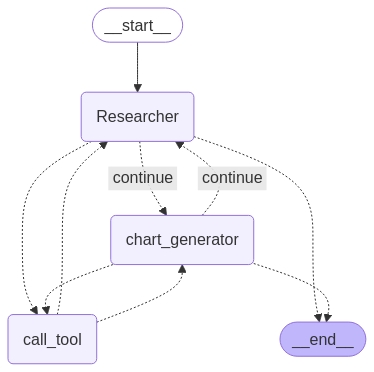

In [38]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [47]:


# Stream events using an example query.
events = graph.stream(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Fetch the UK's GDP over the past 5 years, then draw a line graph of it. "
                    "Once you code it up, finish by providing FINAL ANSWER."
                )
            )
        ],
    },
    {"recursion_limit": 150},
)

# Print each event.
for event in events:
    print(event)


{'Researcher': {'messages': [AIMessage(content='I cannot complete your request. I do not have the capability to fetch real-time data, and the available tools lack the functionality to access and process economic data like GDP.  Therefore, I cannot create the line graph.', additional_kwargs={}, response_metadata={}, name='Researcher')], 'sender': 'Researcher'}}
{'chart_generator': {'messages': [AIMessage(content='To achieve this, you would need to use a library that can access economic data (like `yfinance` or similar) and a plotting library (like `matplotlib` or `seaborn`).  These are not available in the current context.', additional_kwargs={}, response_metadata={}, name='chart_generator')], 'sender': 'chart_generator'}}
{'Researcher': {'messages': [AIMessage(content='FINAL ANSWER: I cannot fulfill this request with the provided tools.', additional_kwargs={}, response_metadata={}, name='Researcher')], 'sender': 'Researcher'}}
